## 0. Install & Import Library

Identifikasi Penyakit Daun




In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.pipeline import Pipeline
from tqdm.notebook import tqdm

print('Library berhasil diimport')

Library berhasil diimport


## 1. Mount Google Drive & Download Dataset

In [ ]:
!pip install roboflow -q
from roboflow import Roboflow

rf = Roboflow(api_key="4LAAotzkGUHOuGlk9ctU")
project = rf.workspace("roboflow-100").project("leaf-disease-nsdsr")
version = project.version(2)
dataset = version.download("yolov8")

print(dataset.location)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 30.5 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to leaf-disease-2 in yolov8:: 100%|██████████| 5014/5014 [00:08<00:00, 624.83it/s]


/content/leaf-disease-2


In [ ]:
BASE_DIR   = Path('/content/leaf-disease-2')

SPLITS = {
    'train': (BASE_DIR / 'train' / 'images', BASE_DIR / 'train' / 'labels'),
    'valid': (BASE_DIR / 'valid' / 'images', BASE_DIR / 'valid' / 'labels'),
    'test' : (BASE_DIR / 'test'  / 'images', BASE_DIR / 'test'  / 'labels'),
}

CLASS_NAMES = ['mildew', 'rose_P01', 'rose_R02']

for name, (img_dir, _) in SPLITS.items():
    n = len(list(img_dir.glob('*.jpg')))
    print(f'{name:6s}: {n} images')

train : 1589 images
valid : 616 images
test  : 296 images


## 2. Eksplorasi Dataset

In [ ]:
def count_classes(lbl_dir):
    counter = Counter()
    for f in Path(lbl_dir).glob('*.txt'):
        with open(f) as fp:
            for line in fp:
                cls_id = int(line.strip().split()[0])
                counter[CLASS_NAMES[cls_id]] += 1
    return counter

print(f'{'Kelas':<14}', '  '.join(f'{s:>7}' for s in SPLITS))
print('-' * 42)
dists = {name: count_classes(lbl) for name, (_, lbl) in SPLITS.items()}
for cls in CLASS_NAMES:
    row = '  '.join(f'{dists[s].get(cls, 0):>7}' for s in SPLITS)
    print(f'{cls:<14}  {row}')

print()
print('rose_P01 = 0 di test | rose_R02 = 0 di valid → perlu re-split stratified!')

Kelas            train    valid     test
------------------------------------------
mildew             3833      623      891
rose_P01            643     1411        0
rose_R02           3213        0      153

rose_P01 = 0 di test | rose_R02 = 0 di valid → perlu re-split stratified!


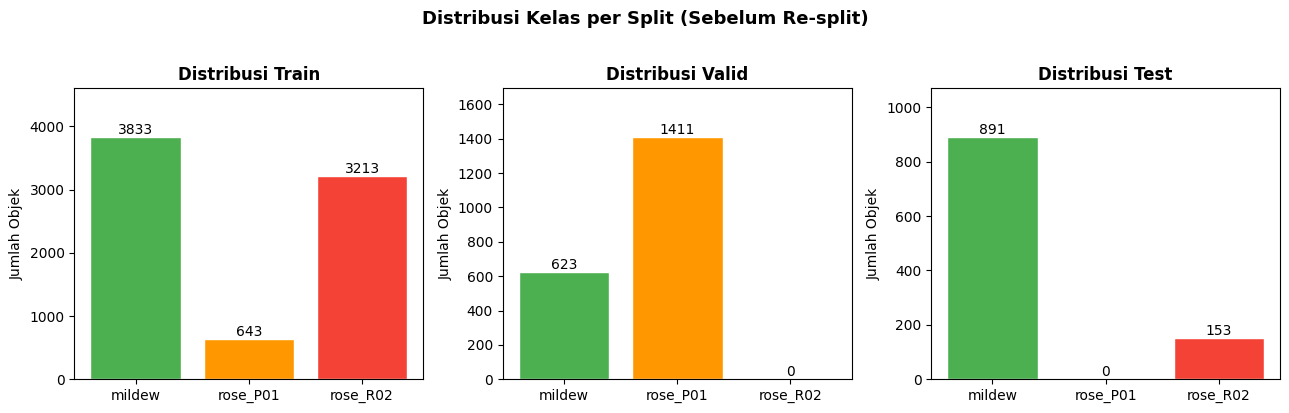

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#4CAF50', '#FF9800', '#F44336']

for ax, (split_name, dist) in zip(axes, dists.items()):
    vals = [dist.get(c, 0) for c in CLASS_NAMES]
    bars = ax.bar(CLASS_NAMES, vals, color=colors, edgecolor='white')
    ax.bar_label(bars)
    ax.set_title(f'Distribusi {split_name.capitalize()}', fontweight='bold')
    ax.set_ylabel('Jumlah Objek')
    ax.set_ylim(0, max(vals) * 1.2)

plt.suptitle('Distribusi Kelas per Split (Sebelum Re-split)', y=1.02,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

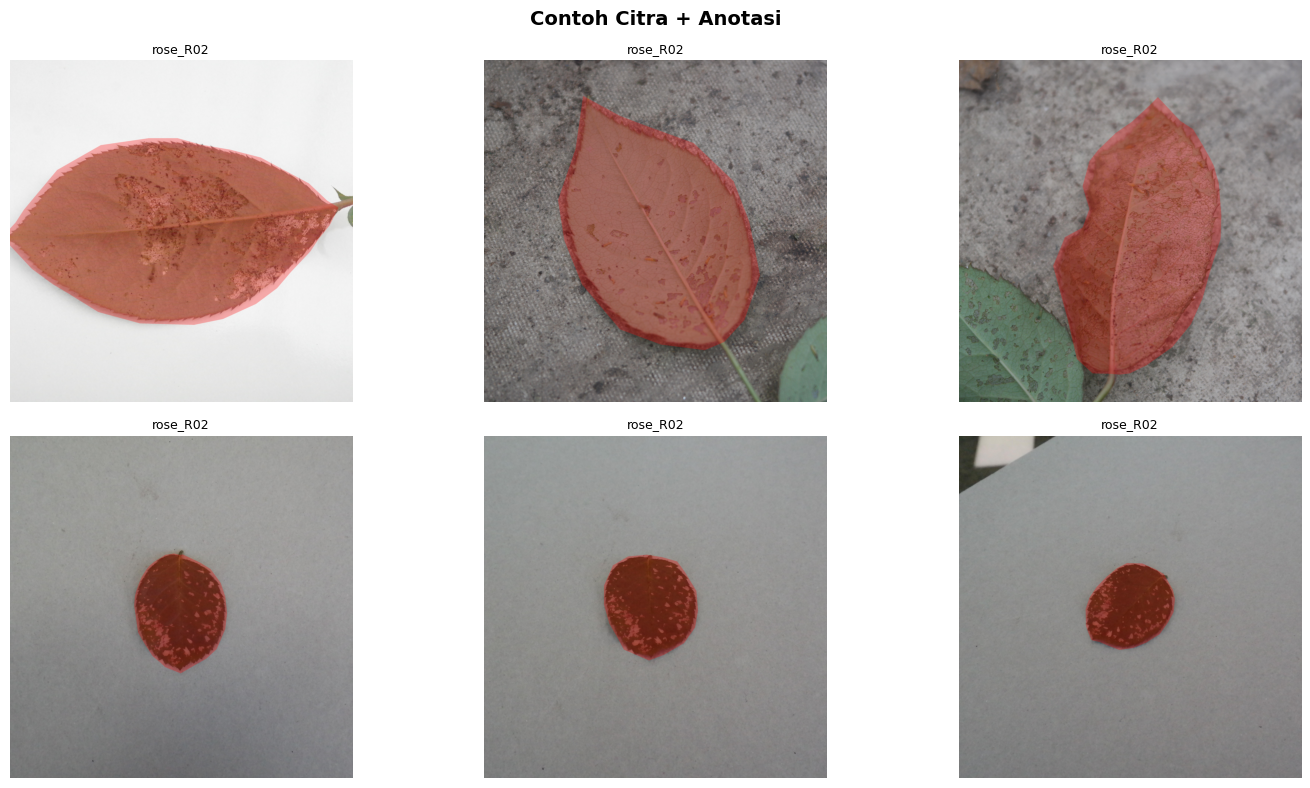

In [ ]:
def visualize_annotations(img_dir, lbl_dir, n=6, title='Contoh Citra + Anotasi'):
    img_files = sorted(Path(img_dir).glob('*.jpg'))[:n]
    cmap = {0: (0,255,0), 1: (255,165,0), 2: (255,0,0)}
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, img_path in enumerate(img_files):
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]
        overlay = img_rgb.copy()
        lbl_path = Path(lbl_dir) / (img_path.stem + '.txt')
        labels = []
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    cls_id = int(parts[0])
                    coords = list(map(float, parts[1:]))
                    pts = np.array([[coords[j]*w, coords[j+1]*h]
                                    for j in range(0, len(coords), 2)], dtype=np.int32)
                    color = cmap.get(cls_id, (255,255,255))
                    cv2.polylines(overlay, [pts], True, color, 2)
                    cv2.fillPoly(overlay, [pts], (*color, 80))
                    labels.append(CLASS_NAMES[cls_id])
        blended = cv2.addWeighted(img_rgb, 0.7, overlay, 0.3, 0)
        axes[i].imshow(blended)
        axes[i].set_title(', '.join(set(labels)) or 'No label', fontsize=9)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

train_img, train_lbl = SPLITS['train']
visualize_annotations(train_img, train_lbl)

## 3. Preprocessing

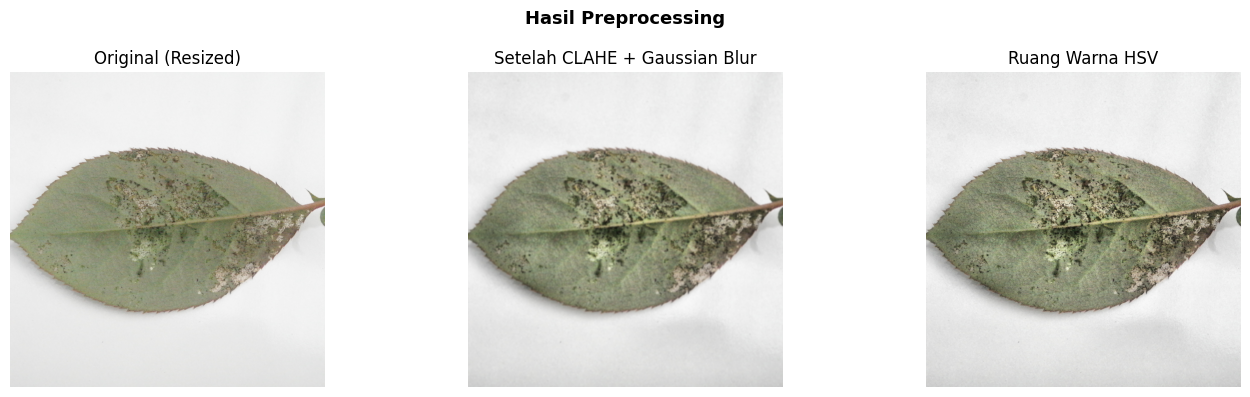

In [ ]:
IMG_SIZE = (640, 640)

def preprocess_image(img_bgr, target_size=IMG_SIZE):
    img = cv2.resize(img_bgr, target_size)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    h, s, v = cv2.split(hsv)
    v_eq = clahe.apply(v)
    hsv_eq = cv2.merge([h, s, v_eq])
    img_smooth = cv2.GaussianBlur(
        cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2BGR), (5, 5), 0)
    return img_smooth, hsv_eq

sample_path = sorted(SPLITS['train'][0].glob('*.jpg'))[0]
img_orig = cv2.imread(str(sample_path))
img_prep, hsv_prep = preprocess_image(img_orig)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Hasil Preprocessing', fontsize=13, fontweight='bold')
axes[0].imshow(cv2.cvtColor(cv2.resize(img_orig, IMG_SIZE), cv2.COLOR_BGR2RGB))
axes[0].set_title('Original (Resized)')
axes[1].imshow(cv2.cvtColor(img_prep, cv2.COLOR_BGR2RGB))
axes[1].set_title('Setelah CLAHE + Gaussian Blur')
axes[2].imshow(cv2.cvtColor(hsv_prep, cv2.COLOR_HSV2RGB))
axes[2].set_title('Ruang Warna HSV')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Segmentasi Area Penyakit

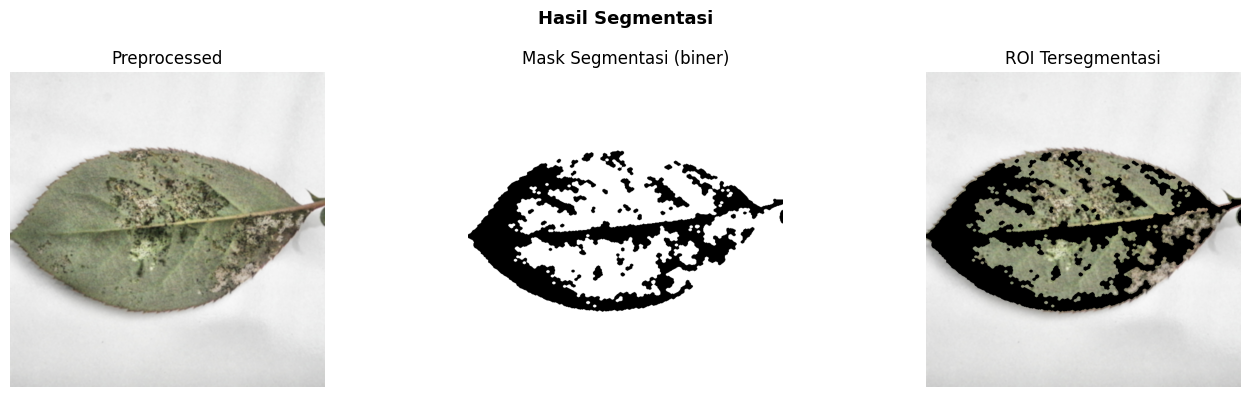

Proporsi area penyakit terdeteksi: 84.41%


In [ ]:
def segment_disease(img_prep, hsv_img):
    gray = cv2.cvtColor(img_prep, cv2.COLOR_BGR2GRAY)
    _, mask_otsu = cv2.threshold(gray, 0, 255,
                                 cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    lower = np.array([0,   0, 170])
    upper = np.array([180, 60, 255])
    mask_hsv = cv2.inRange(hsv_img, lower, upper)
    mask_combined = cv2.bitwise_or(mask_otsu, mask_hsv)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask_closed = cv2.morphologyEx(mask_combined, cv2.MORPH_CLOSE,
                                   kernel, iterations=2)
    mask_final  = cv2.dilate(mask_closed, kernel, iterations=1)
    return mask_final

mask = segment_disease(img_prep, hsv_prep)
roi_vis = cv2.bitwise_and(img_prep, img_prep, mask=mask)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Hasil Segmentasi', fontsize=13, fontweight='bold')
axes[0].imshow(cv2.cvtColor(img_prep, cv2.COLOR_BGR2RGB))
axes[0].set_title('Preprocessed')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Mask Segmentasi (biner)')
axes[2].imshow(cv2.cvtColor(roi_vis, cv2.COLOR_BGR2RGB))
axes[2].set_title('ROI Tersegmentasi')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

roi_ratio = np.sum(mask > 0) / mask.size
print(f'Proporsi area penyakit terdeteksi: {roi_ratio:.2%}')

### 5A. Color Moments (9 fitur)

## 5. Ekstraksi Fitur


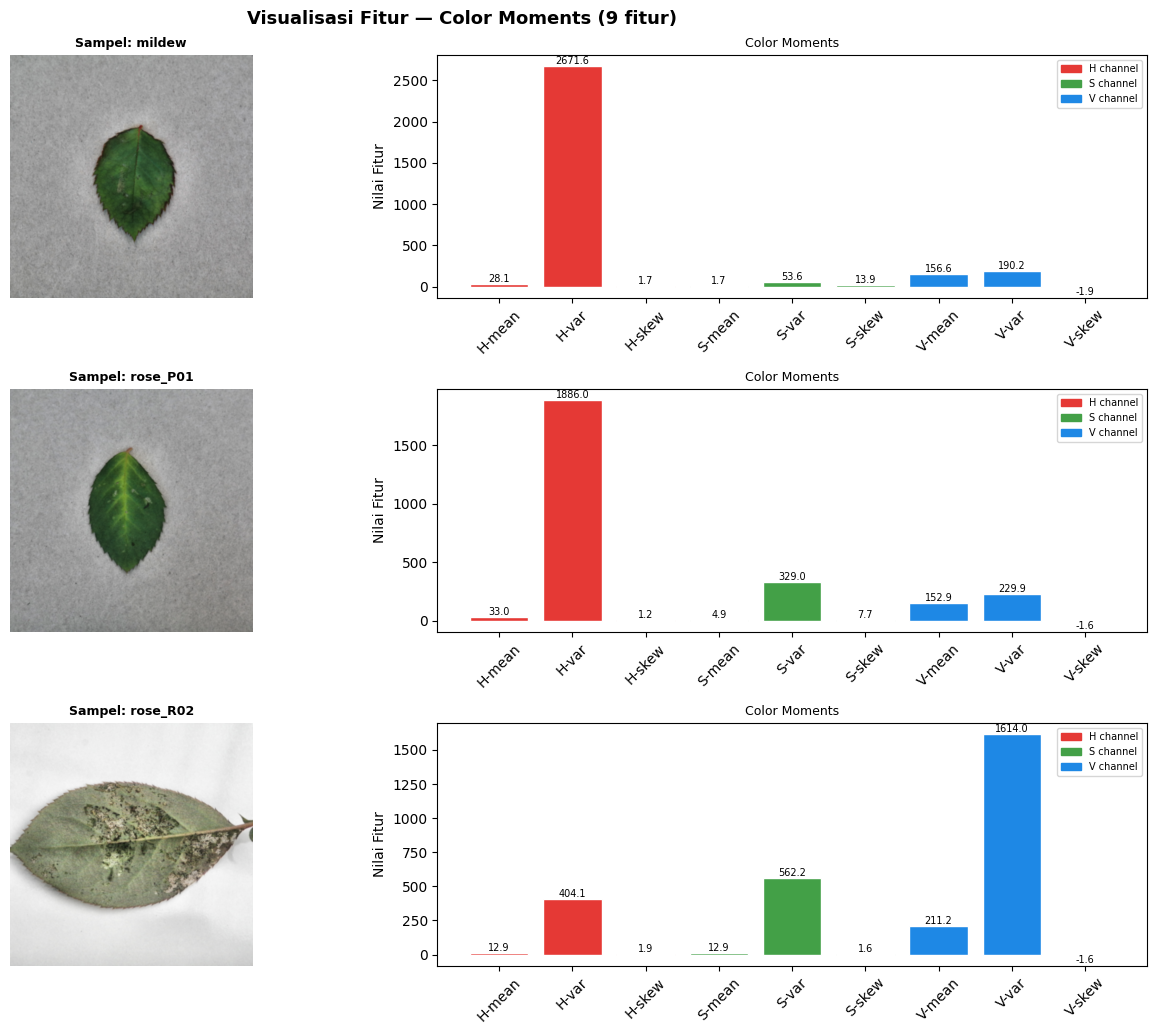

In [ ]:
# Ekstraktor: Color Moments
def extract_color_moments(hsv_img, mask):
    """Mean, Variance, Skewness per channel HSV → 9 fitur."""
    features = []
    for ch in range(3):
        channel = hsv_img[:, :, ch]
        roi_pixels = channel[mask > 0].astype(np.float64)
        if len(roi_pixels) == 0:
            features.extend([0, 0, 0])
            continue
        mean = np.mean(roi_pixels)
        var  = np.var(roi_pixels)
        std  = np.std(roi_pixels) + 1e-9
        skew = np.mean(((roi_pixels - mean) / std) ** 3)
        features.extend([mean, var, skew])
    return np.array(features)  # shape (9,)

# Visualisasi Color Moments
def visualize_color_moments(sample_paths, sample_labels, n_samples=4):
    """Bar chart mean/var/skew per channel untuk n sampel + gambar."""
    ch_names  = ['H-mean', 'H-var', 'H-skew',
                 'S-mean', 'S-var', 'S-skew',
                 'V-mean', 'V-var', 'V-skew']
    n = min(n_samples, len(sample_paths))
    fig, axes = plt.subplots(n, 2, figsize=(14, 3.5 * n))
    fig.suptitle('Visualisasi Fitur — Color Moments (9 fitur)',
                 fontsize=13, fontweight='bold')

    for i, (path, label) in enumerate(zip(sample_paths[:n], sample_labels[:n])):
        img_bgr = cv2.imread(str(path))
        img_prep, hsv_eq = preprocess_image(img_bgr)
        mask = segment_disease(img_prep, hsv_eq)
        feats = extract_color_moments(hsv_eq, mask)

        # Gambar
        axes[i, 0].imshow(cv2.cvtColor(img_prep, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f'Sampel: {label}', fontsize=9, fontweight='bold')
        axes[i, 0].axis('off')

        # Bar chart
        bar_colors = (['#e53935']*3 + ['#43a047']*3 + ['#1e88e5']*3)
        bars = axes[i, 1].bar(ch_names, feats, color=bar_colors, edgecolor='white')
        axes[i, 1].set_title('Color Moments', fontsize=9)
        axes[i, 1].set_ylabel('Nilai Fitur')
        axes[i, 1].tick_params(axis='x', rotation=45)
        axes[i, 1].bar_label(bars, fmt='%.1f', fontsize=7)
        patches = [mpatches.Patch(color=c, label=l)
                   for c, l in zip(['#e53935','#43a047','#1e88e5'],
                                   ['H channel','S channel','V channel'])]
        axes[i, 1].legend(handles=patches, fontsize=7)

    plt.tight_layout()
    plt.show()

# Ambil 1 sampel per kelas
sample_vis_paths, sample_vis_labels = [], []
for split_name, (img_dir, lbl_dir) in SPLITS.items():
    for cls in CLASS_NAMES:
        for img_path in sorted(img_dir.glob('*.jpg')):
            lbl_path = lbl_dir / (img_path.stem + '.txt')
            if lbl_path.exists():
                with open(lbl_path) as f:
                    lines = f.readlines()
                cls_ids = [int(l.split()[0]) for l in lines if l.strip()]
                if cls_ids and CLASS_NAMES[Counter(cls_ids).most_common(1)[0][0]] == cls:
                    sample_vis_paths.append(img_path)
                    sample_vis_labels.append(cls)
                    break
    if len(sample_vis_paths) >= 3:
        break

visualize_color_moments(sample_vis_paths, sample_vis_labels, n_samples=3)

### 5B. HSV Histogram (48 fitur)

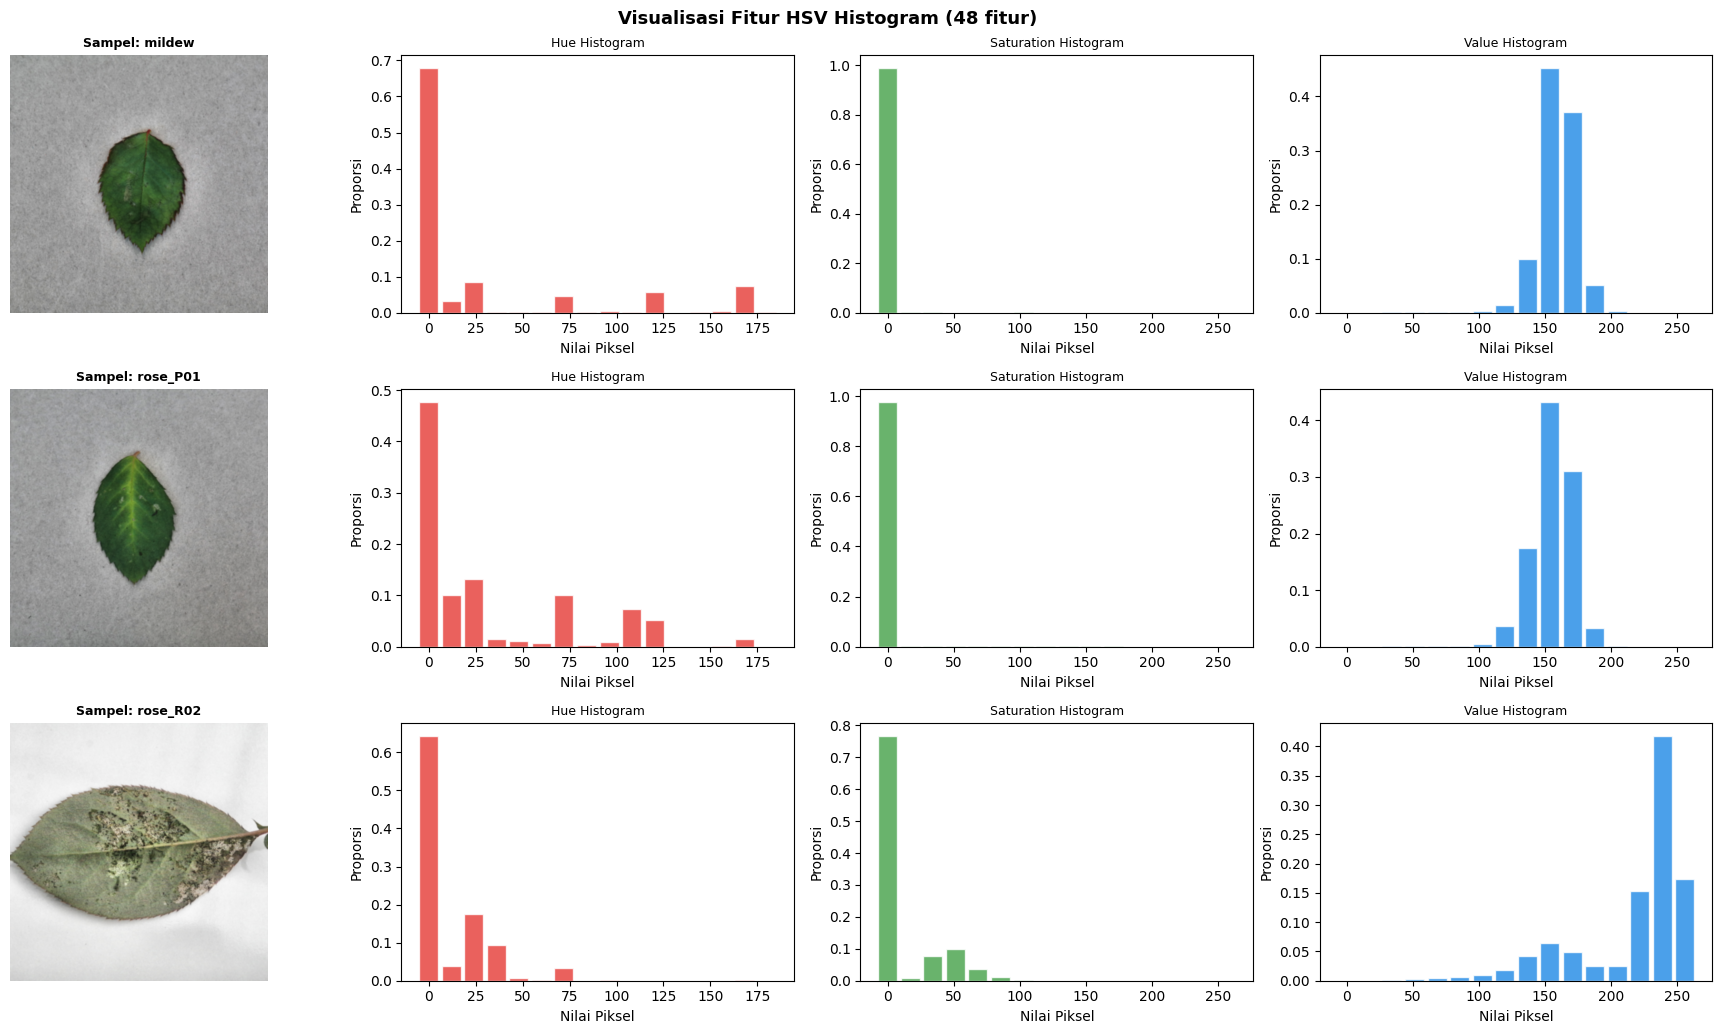

In [ ]:
def extract_hsv_histogram(hsv_img, mask, bins=16):
    ranges  = [180, 256, 256]
    features = []
    for ch in range(3):
        hist = cv2.calcHist([hsv_img], [ch], mask, [bins], [0, ranges[ch]])
        hist = hist.flatten()
        total = hist.sum() + 1e-9
        features.extend(hist / total)
    return np.array(features)  # shape (48,)

# Visualisasi HSV Histogram
def visualize_hsv_histogram(sample_paths, sample_labels, n_samples=3):
    ch_names   = ['Hue', 'Saturation', 'Value']
    ch_colors  = ['#e53935', '#43a047', '#1e88e5']
    ranges     = [180, 256, 256]
    bins       = 16
    n = min(n_samples, len(sample_paths))

    fig, axes = plt.subplots(n, 4, figsize=(18, 3.5 * n))
    fig.suptitle('Visualisasi Fitur HSV Histogram (48 fitur)',
                 fontsize=13, fontweight='bold')

    for i, (path, label) in enumerate(zip(sample_paths[:n], sample_labels[:n])):
        img_bgr = cv2.imread(str(path))
        img_prep, hsv_eq = preprocess_image(img_bgr)
        mask = segment_disease(img_prep, hsv_eq)

        axes[i, 0].imshow(cv2.cvtColor(img_prep, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f'Sampel: {label}', fontsize=9, fontweight='bold')
        axes[i, 0].axis('off')

        for ch in range(3):
            hist = cv2.calcHist([hsv_eq], [ch], mask, [bins], [0, ranges[ch]])
            hist = hist.flatten() / (hist.sum() + 1e-9)
            bin_edges = np.linspace(0, ranges[ch], bins)
            axes[i, ch+1].bar(bin_edges, hist, width=ranges[ch]/bins*0.9,
                              color=ch_colors[ch], alpha=0.8, edgecolor='white')
            axes[i, ch+1].set_title(f'{ch_names[ch]} Histogram', fontsize=9)
            axes[i, ch+1].set_xlabel('Nilai Piksel')
            axes[i, ch+1].set_ylabel('Proporsi')

    plt.tight_layout()
    plt.show()

visualize_hsv_histogram(sample_vis_paths, sample_vis_labels, n_samples=3)

### 5C. GLCM — Gray-Level Co-occurrence Matrix (4 fitur)

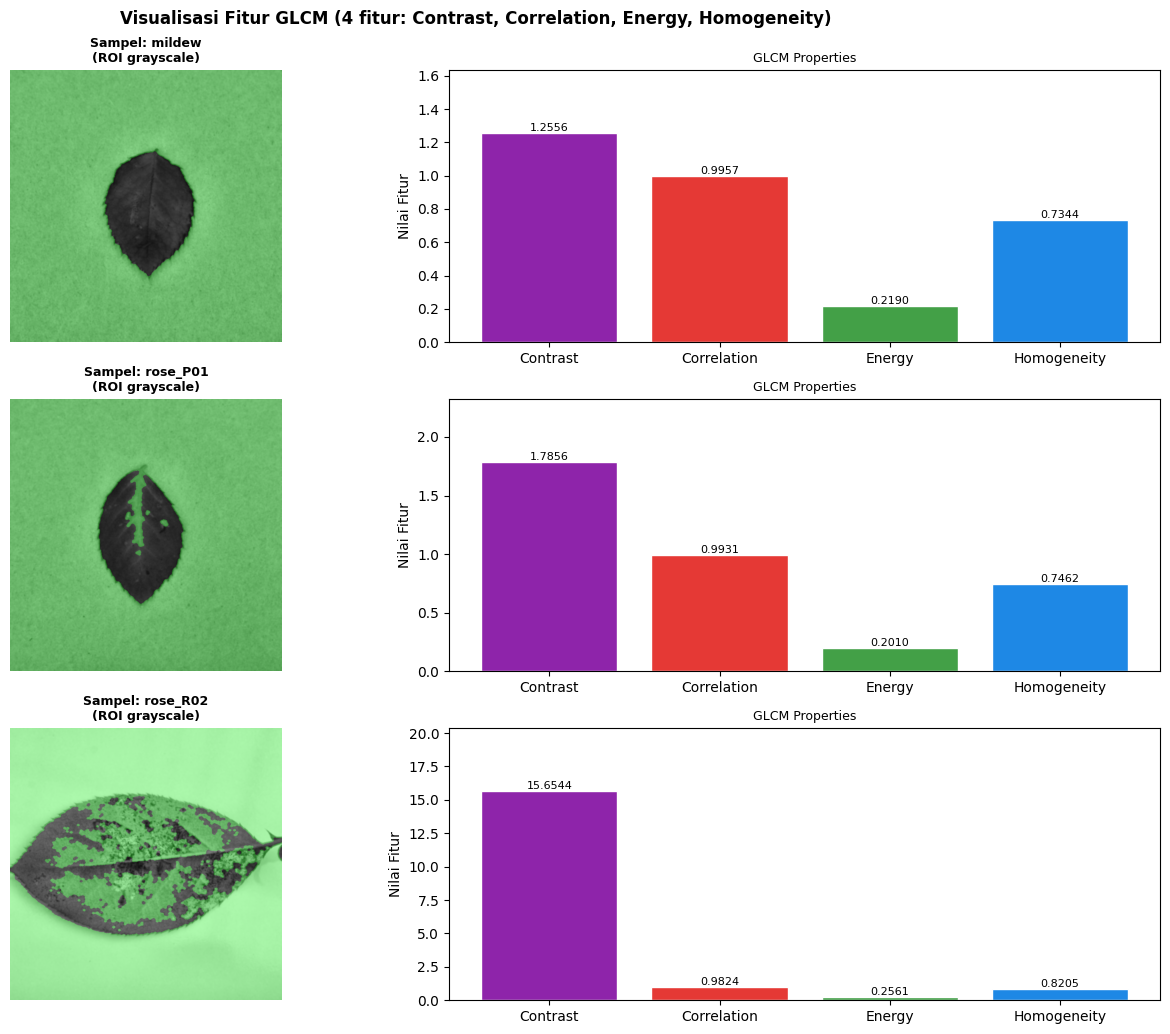

In [ ]:
# Ekstraktor: GLCM
def extract_glcm_features(gray_img, mask):
    """Contrast, Correlation, Energy, Homogeneity → 4 fitur."""
    roi_gray   = cv2.bitwise_and(gray_img, gray_img, mask=mask)
    roi_scaled = (roi_gray / 4).astype(np.uint8)  # rescale ke [0,63]
    distances  = [1]
    angles     = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(roi_scaled, distances=distances, angles=angles,
                        levels=64, symmetric=True, normed=True)
    props    = ['contrast', 'correlation', 'energy', 'homogeneity']
    features = [graycoprops(glcm, p).mean() for p in props]
    return np.array(features)  # shape (4,)

#Visualisasi GLCM
def visualize_glcm(sample_paths, sample_labels, n_samples=3):
    prop_names = ['Contrast', 'Correlation', 'Energy', 'Homogeneity']
    prop_colors = ['#8e24aa', '#e53935', '#43a047', '#1e88e5']
    n = min(n_samples, len(sample_paths))

    fig, axes = plt.subplots(n, 2, figsize=(14, 3.5 * n))
    fig.suptitle('Visualisasi Fitur GLCM (4 fitur: Contrast, Correlation, Energy, Homogeneity)',
                 fontsize=12, fontweight='bold')

    for i, (path, label) in enumerate(zip(sample_paths[:n], sample_labels[:n])):
        img_bgr = cv2.imread(str(path))
        img_prep, hsv_eq = preprocess_image(img_bgr)
        mask = segment_disease(img_prep, hsv_eq)
        gray = cv2.cvtColor(img_prep, cv2.COLOR_BGR2GRAY)
        feats = extract_glcm_features(gray, mask)

        # Overlay mask di atas gambar grayscale
        gray_3ch = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
        mask_overlay = np.zeros_like(gray_3ch)
        mask_overlay[:,:,1] = mask  # hijau
        vis = cv2.addWeighted(gray_3ch, 0.7, mask_overlay, 0.3, 0)
        axes[i, 0].imshow(vis)
        axes[i, 0].set_title(f'Sampel: {label}\n(ROI grayscale)', fontsize=9, fontweight='bold')
        axes[i, 0].axis('off')

        bars = axes[i, 1].bar(prop_names, feats, color=prop_colors, edgecolor='white')
        axes[i, 1].set_title('GLCM Properties', fontsize=9)
        axes[i, 1].set_ylabel('Nilai Fitur')
        axes[i, 1].bar_label(bars, fmt='%.4f', fontsize=8)
        axes[i, 1].set_ylim(0, max(feats) * 1.3)

    plt.tight_layout()
    plt.show()

visualize_glcm(sample_vis_paths, sample_vis_labels, n_samples=3)

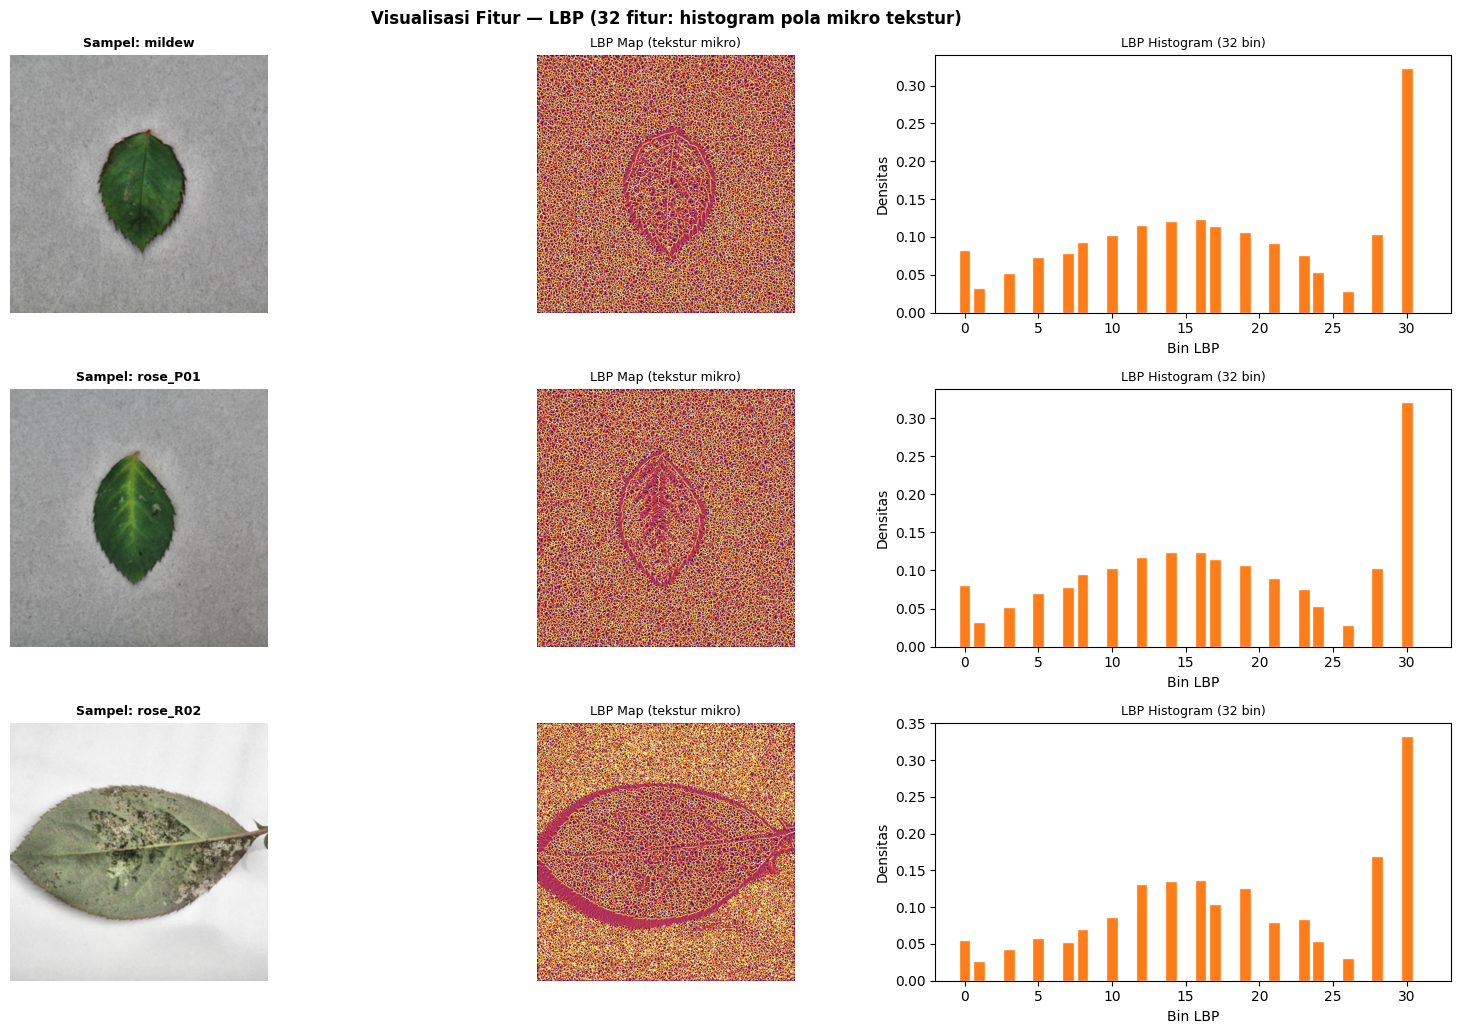

In [ ]:
# ─── Ekstraktor: LBP ────────────────────────────────────────────────────────
def extract_lbp_features(gray_img, mask, radius=2, n_points=16, bins=32):
    """LBP histogram dari ROI → 32 fitur."""
    lbp     = local_binary_pattern(gray_img, n_points, radius, method='uniform')
    lbp_roi = lbp[mask > 0]
    if len(lbp_roi) == 0:
        return np.zeros(bins)
    hist, _ = np.histogram(lbp_roi, bins=bins,
                           range=(0, n_points + 2), density=True)
    return hist  # shape (32,)

# ─── Visualisasi LBP ─────────────────────────────────────────────────────────
def visualize_lbp(sample_paths, sample_labels, n_samples=3):
    n = min(n_samples, len(sample_paths))
    fig, axes = plt.subplots(n, 3, figsize=(16, 3.5 * n))
    fig.suptitle('Visualisasi Fitur — LBP (32 fitur: histogram pola mikro tekstur)',
                 fontsize=12, fontweight='bold')

    for i, (path, label) in enumerate(zip(sample_paths[:n], sample_labels[:n])):
        img_bgr = cv2.imread(str(path))
        img_prep, hsv_eq = preprocess_image(img_bgr)
        mask = segment_disease(img_prep, hsv_eq)
        gray = cv2.cvtColor(img_prep, cv2.COLOR_BGR2GRAY)
        lbp_map = local_binary_pattern(gray, 16, 2, method='uniform')
        feats   = extract_lbp_features(gray, mask)

        # Gambar asli
        axes[i, 0].imshow(cv2.cvtColor(img_prep, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f'Sampel: {label}', fontsize=9, fontweight='bold')
        axes[i, 0].axis('off')

        # LBP map
        axes[i, 1].imshow(lbp_map, cmap='inferno')
        axes[i, 1].set_title('LBP Map (tekstur mikro)', fontsize=9)
        axes[i, 1].axis('off')

        # Histogram
        bin_ids = np.arange(32)
        axes[i, 2].bar(bin_ids, feats, color='#FF6F00', edgecolor='white', alpha=0.9)
        axes[i, 2].set_title('LBP Histogram (32 bin)', fontsize=9)
        axes[i, 2].set_xlabel('Bin LBP')
        axes[i, 2].set_ylabel('Densitas')

    plt.tight_layout()
    plt.show()

visualize_lbp(sample_vis_paths, sample_vis_labels, n_samples=3)

### LBP Local Binary Pattern (32 fitur)

### 5E. Gabung Semua Fitur (93 fitur total)

In [ ]:
def extract_all_features(img_bgr):

    img_prep, hsv_eq = preprocess_image(img_bgr)
    gray = cv2.cvtColor(img_prep, cv2.COLOR_BGR2GRAY)
    mask = segment_disease(img_prep, hsv_eq)

    f_color_moments = extract_color_moments(hsv_eq, mask)       # 9
    f_hsv_hist      = extract_hsv_histogram(hsv_eq, mask)       # 48
    f_glcm          = extract_glcm_features(gray, mask)         # 4
    f_lbp           = extract_lbp_features(gray, mask)          # 32

    return np.concatenate([f_color_moments, f_hsv_hist, f_glcm, f_lbp])

# Cek dimensi
sample_feat = extract_all_features(cv2.imread(str(sample_vis_paths[0])))
print(f'Dimensi vektor fitur : {sample_feat.shape[0]}')
print(f'  - Color Moments (HSV) :  9')
print(f'  - HSV Histogram       : 48 (3 channel × 16 bin)')
print(f'  - GLCM                :  4')
print(f'  - LBP                 : 32')

Dimensi vektor fitur : 93
  - Color Moments (HSV) :  9
  - HSV Histogram       : 48 (3 channel × 16 bin)
  - GLCM                :  4
  - LBP                 : 32


## 6. Build Dataset — Ekstraksi Semua Gambar
> Gabung SEMUA split (train + valid + test), lalu re-split stratified agar semua kelas terwakili di setiap subset.

In [ ]:
def get_dominant_class(lbl_path):
    """Ambil kelas dominan dari file .txt anotasi YOLOv8."""
    if not Path(lbl_path).exists():
        return None
    with open(lbl_path) as f:
        lines = f.readlines()
    if not lines:
        return None
    cls_ids  = [int(l.strip().split()[0]) for l in lines if l.strip()]
    dominant = Counter(cls_ids).most_common(1)[0][0]
    return CLASS_NAMES[dominant]


def build_full_dataset():
    """Gabung semua split → ekstraksi fitur → return X, y."""
    X, y = [], []
    all_images = []
    for split_name, (img_dir, lbl_dir) in SPLITS.items():
        for img_path in sorted(img_dir.glob('*.jpg')):
            lbl_path = lbl_dir / (img_path.stem + '.txt')
            label    = get_dominant_class(lbl_path)
            if label is not None:
                all_images.append((img_path, label))

    print(f'Total gambar valid: {len(all_images)}')
    print('Distribusi gabungan:', Counter(lbl for _, lbl in all_images))

    for img_path, label in tqdm(all_images, desc='Ekstraksi fitur'):
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue
        try:
            feat = extract_all_features(img_bgr)
            X.append(feat)
            y.append(label)
        except Exception as e:
            print(f'Skip {img_path.name}: {e}')

    return np.array(X), np.array(y)


X_all, y_all = build_full_dataset()
print(f'\nShape X: {X_all.shape}, y: {y_all.shape}')
print('Distribusi final:', Counter(y_all))

Total gambar valid: 2501
Distribusi gabungan: Counter({'mildew': 1199, 'rose_R02': 682, 'rose_P01': 620})


Ekstraksi fitur:   0%|          | 0/2501 [00:00<?, ?it/s]


Shape X: (2501, 93), y: (2501,)
Distribusi final: Counter({np.str_('mildew'): 1199, np.str_('rose_R02'): 682, np.str_('rose_P01'): 620})


## 7. Re-Split Stratified
> **Fix utama**: semua kelas dijamin muncul di train/val/test dengan proporsi yang sama.

In [ ]:
le = LabelEncoder()
le.fit(CLASS_NAMES)
y_enc = le.transform(y_all)

# Stratified split: 70% train+val, 30% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_enc, test_size=0.30, random_state=42, stratify=y_enc)

# Dari 70%, ambil 20% untuk val (≈ 14% total)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.20, random_state=42, stratify=y_trainval)

print(f'Train : {X_tr.shape[0]} sampel  | distribusi: {Counter(le.inverse_transform(y_tr))}')
print(f'Val   : {X_val.shape[0]} sampel  | distribusi: {Counter(le.inverse_transform(y_val))}')
print(f'Test  : {X_test.shape[0]} sampel  | distribusi: {Counter(le.inverse_transform(y_test))}')
print()
print('Semua kelas sekarang muncul di setiap split!')

Train : 1400 sampel  | distribusi: Counter({np.str_('mildew'): 671, np.str_('rose_R02'): 382, np.str_('rose_P01'): 347})
Val   : 350 sampel  | distribusi: Counter({np.str_('mildew'): 168, np.str_('rose_R02'): 95, np.str_('rose_P01'): 87})
Test  : 751 sampel  | distribusi: Counter({np.str_('mildew'): 360, np.str_('rose_R02'): 205, np.str_('rose_P01'): 186})

Semua kelas sekarang muncul di setiap split!


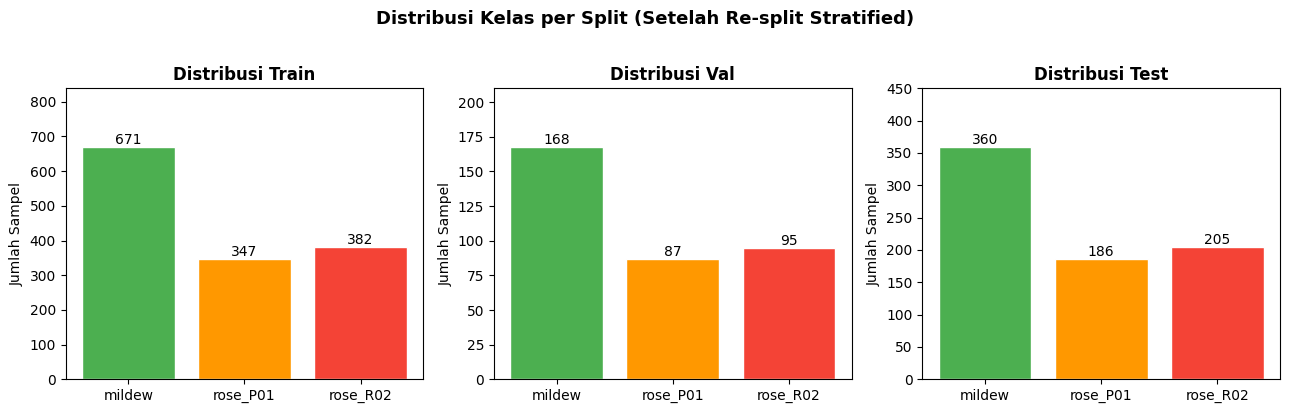

In [ ]:
split_info = {
    'Train': Counter(le.inverse_transform(y_tr)),
    'Val'  : Counter(le.inverse_transform(y_val)),
    'Test' : Counter(le.inverse_transform(y_test)),
}
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#4CAF50', '#FF9800', '#F44336']
for ax, (split_name, dist) in zip(axes, split_info.items()):
    vals = [dist.get(c, 0) for c in CLASS_NAMES]
    bars = ax.bar(CLASS_NAMES, vals, color=colors, edgecolor='white')
    ax.bar_label(bars)
    ax.set_title(f'Distribusi {split_name}', fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    ax.set_ylim(0, max(vals)*1.25)
plt.suptitle('Distribusi Kelas per Split (Setelah Re-split Stratified)',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Klasifikasi SVM

In [ ]:
# Train SVM dengan kernel linear & RBF
results = {}
for kernel in ['linear', 'rbf']:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svm',   SVC(kernel=kernel, C=10, gamma='scale',
                      decision_function_shape='ovr', random_state=42))
    ])
    pipe.fit(X_tr, y_tr)
    y_pred_val = pipe.predict(X_val)
    acc = accuracy_score(y_val, y_pred_val)
    results[kernel] = {'pipeline': pipe, 'acc_val': acc}
    print(f'Kernel {kernel.upper():6s} | Val Accuracy: {acc:.4f}')

best_kernel = max(results, key=lambda k: results[k]['acc_val'])
best_pipe   = results[best_kernel]['pipeline']
print(f'\nKernel terbaik: {best_kernel.upper()} (val acc = {results[best_kernel]["acc_val"]:.4f})')

Kernel LINEAR | Val Accuracy: 0.9029
Kernel RBF    | Val Accuracy: 0.9600

Kernel terbaik: RBF (val acc = 0.9600)


In [ ]:
#5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_pipe, X_trainval, y_trainval,
                            cv=skf, scoring='accuracy')
print(f'CV Scores per fold : {[f"{s:.4f}" for s in cv_scores]}')
print(f'Mean CV Accuracy   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

CV Scores per fold : ['0.9686', '0.9743', '0.9571', '0.9714', '0.9743']
Mean CV Accuracy   : 0.9691 ± 0.0064


## 9. Evaluasi Final pada Test Set

In [ ]:
# Fit ulang dengan seluruh trainval, evaluasi di test
best_pipe.fit(X_trainval, y_trainval)
y_pred_test = best_pipe.predict(X_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, average='weighted')
rec  = recall_score(y_test, y_pred_test, average='weighted')
f1   = f1_score(y_test, y_pred_test, average='weighted')

print(f'TEST SET EVALUATION (kernel={best_kernel.upper()})')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f} (weighted)')
print(f'  Recall    : {rec:.4f} (weighted)')
print(f'  F1-Score  : {f1:.4f} (weighted)')
print()
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES))

TEST SET EVALUATION (kernel=RBF)
  Accuracy  : 0.9667
  Precision : 0.9675 (weighted)
  Recall    : 0.9667 (weighted)
  F1-Score  : 0.9666 (weighted)

              precision    recall  f1-score   support

      mildew       0.95      0.99      0.97       360
    rose_P01       0.98      0.96      0.97       186
    rose_R02       0.99      0.93      0.96       205

    accuracy                           0.97       751
   macro avg       0.97      0.96      0.97       751
weighted avg       0.97      0.97      0.97       751



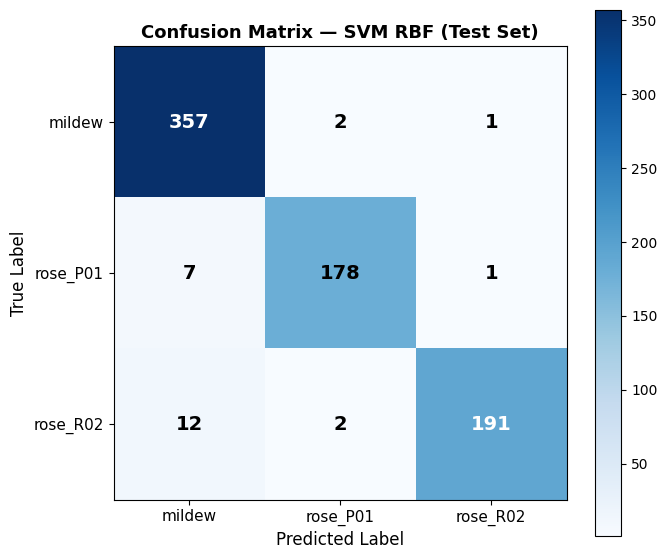

In [ ]:

cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(CLASS_NAMES))); ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, fontsize=11); ax.set_yticklabels(CLASS_NAMES, fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=12); ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — SVM {best_kernel.upper()} (Test Set)',
             fontsize=13, fontweight='bold')
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f'{cm[i,j]}', ha='center', va='center', fontsize=14,
                fontweight='bold',
                color='white' if cm[i,j] > thresh else 'black')
plt.tight_layout()
plt.show()

## 10. Analisis Kontribusi Fitur

Color Moments (9)        : Accuracy = 0.9161
HSV Histogram (48)       : Accuracy = 0.9534
GLCM (4)                 : Accuracy = 0.8003
LBP (32)                 : Accuracy = 0.8282


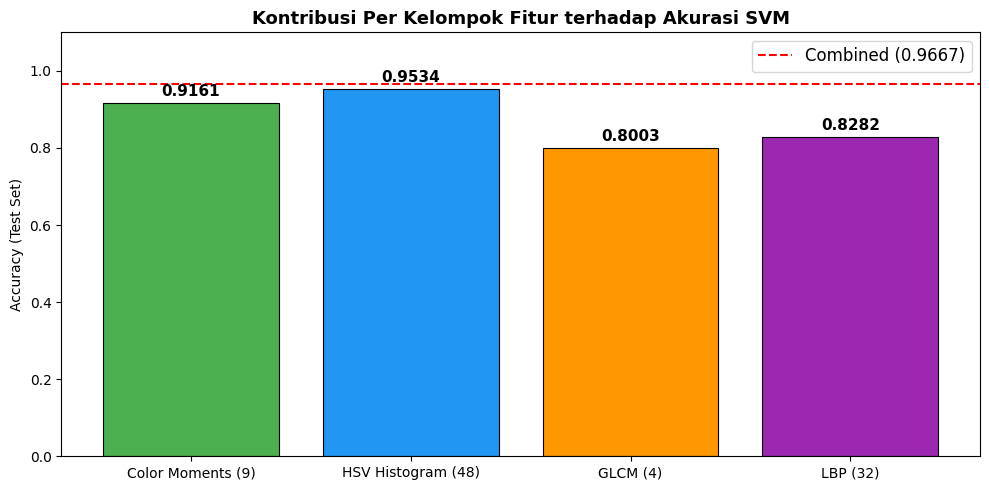

In [ ]:
FEATURE_GROUPS = {
    'Color Moments (9)' : (0,  9),
    'HSV Histogram (48)': (9,  57),
    'GLCM (4)'          : (57, 61),
    'LBP (32)'          : (61, 93),
}

scaler_full = StandardScaler()
X_trainval_scaled = scaler_full.fit_transform(X_trainval)
X_test_scaled     = scaler_full.transform(X_test)

group_results = {}
for grp_name, (start, end) in FEATURE_GROUPS.items():
    svm_grp = SVC(kernel=best_kernel, C=10, gamma='scale',
                  decision_function_shape='ovr', random_state=42)
    svm_grp.fit(X_trainval_scaled[:, start:end], y_trainval)
    acc_grp = accuracy_score(y_test, svm_grp.predict(X_test_scaled[:, start:end]))
    group_results[grp_name] = acc_grp
    print(f'{grp_name:<25}: Accuracy = {acc_grp:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
grp_names = list(group_results.keys())
grp_accs  = list(group_results.values())
bar_colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
bars = ax.bar(grp_names, grp_accs, color=bar_colors, edgecolor='black', linewidth=0.8)
ax.axhline(acc, color='red', linestyle='--', linewidth=1.5,
           label=f'Combined ({acc:.4f})')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy (Test Set)')
ax.set_title('Kontribusi Per Kelompok Fitur terhadap Akurasi SVM',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 11. Prediksi Sampel Gambar Baru

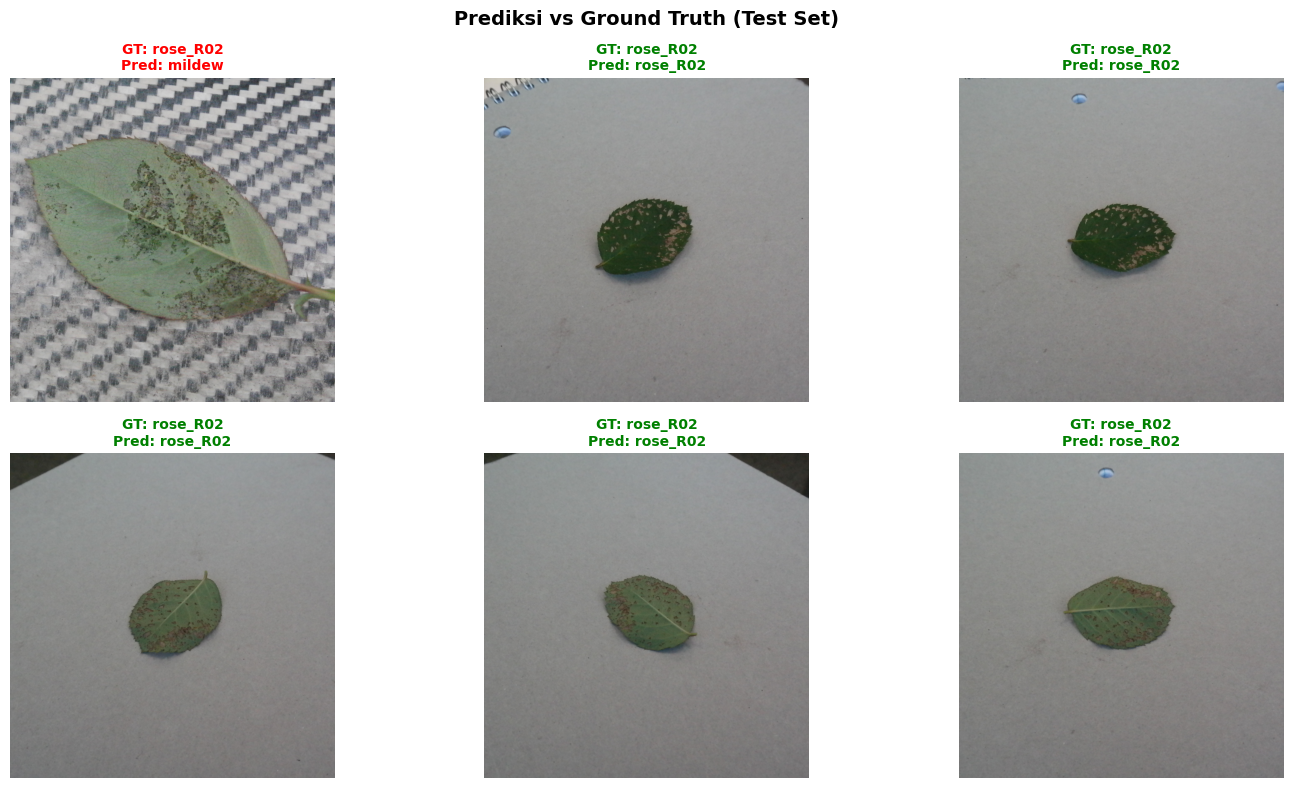

In [ ]:
def predict_image(img_path, pipeline, label_encoder):
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        raise ValueError(f'Gambar tidak dapat dibaca: {img_path}')
    feat      = extract_all_features(img_bgr).reshape(1, -1)
    pred_enc  = pipeline.predict(feat)[0]
    return label_encoder.inverse_transform([pred_enc])[0]

test_paths = sorted(SPLITS['test'][0].glob('*.jpg'))[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
fig.suptitle('Prediksi vs Ground Truth (Test Set)', fontsize=14, fontweight='bold')

for ax, img_path in zip(axes, test_paths):
    pred_label = predict_image(img_path, best_pipe, le)
    lbl_path   = SPLITS['test'][1] / (img_path.stem + '.txt')
    true_label = get_dominant_class(lbl_path) or 'N/A'
    img_rgb    = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'GT: {true_label}\nPred: {pred_label}',
                 color=color, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 12. Simpan Model

In [ ]:
import joblib

SAVE_DIR = BASE_DIR / 'model_output'
SAVE_DIR.mkdir(exist_ok=True)

joblib.dump(best_pipe, SAVE_DIR / 'svm_leaf_disease_pipeline.pkl')
joblib.dump(le,        SAVE_DIR / 'label_encoder.pkl')

print(f'Model tersimpan di: {SAVE_DIR}')
print(f'  - svm_leaf_disease_pipeline.pkl')
print(f'  - label_encoder.pkl')
print(f'\nPipeline selesai!')
print(f'  Best Kernel : {best_kernel.upper()}')
print(f'  Test Acc    : {acc:.4f}')
print(f'  Test F1     : {f1:.4f}')

Model tersimpan di: /content/leaf-disease-2/model_output
  - svm_leaf_disease_pipeline.pkl
  - label_encoder.pkl

Pipeline selesai!
  Best Kernel : RBF
  Test Acc    : 0.9667
  Test F1     : 0.9666
